<a href="https://colab.research.google.com/github/Curiousminded06/micrograd/blob/main/micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [202]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [203]:
def f(x):
  return 3*x**2-4*x+5

In [204]:
f(3.0)

20.0

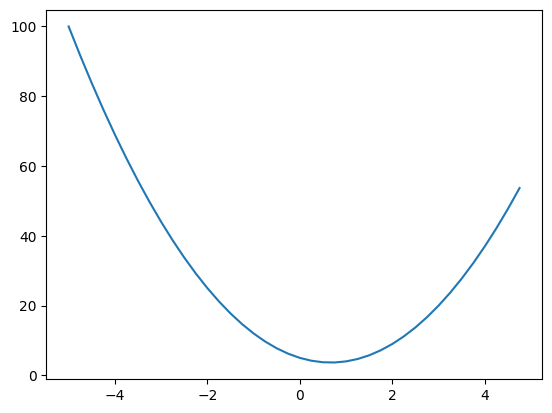

In [205]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [206]:
#derivative
h=0.000000001
x=2/3
(f(x+h)-f(x))/h


0.0

In [207]:
#les get more complex
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)


4.0


In [208]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0

d1=a*b+c
c+=h
d2=a*b+c
print(d1)
print(d2)
da=(d2-d1)/h
print("slope",da)

4.0
4.0001
slope 0.9999999999976694


In [209]:
#Forward Pass
class Value:

  def __init__(self,data,_children=(),_op="",label=""):
    self.data=data
    self.grad=0.0 #Back propogates
    self._prev=set(_children) #efficiency
    self._backward=lambda:None #backward propogation
    self._op=_op
    self.label=label
  def __repr__(self):  # to print nice expression in python otherwise it'll return a vague result hard to understand
    return f"Value(data={self.data})"
  def __add__(self,other):
     other=other if isinstance(other,Value) else Value(other)
     out=Value(self.data+other.data,(self,other),"+")
     def _backward():
       self.grad+=1.0*out.grad
       other.grad+=1.0*out.grad
     out._backward=_backward
     return out
  def __mul__(self,other):
      other=other if isinstance(other,Value) else Value(other)
      out= Value(self.data*other.data,(self,other),"*")
      def _backward():
        self.grad+=other.data*out.grad
        other.grad+=self.data*out.grad
      out._backward=_backward
      return out
  def __truediv__(self,other): #self/other
    return self*other**-1
  def __rtruediv__(self, other): # other / self
        return other * self**-1
  def __neg__(self):
    return self*-1
  def __sub__(self,other):
    return self+(-other)
  def __rsub__(self,other):
    return other+(-self)
  def __radd__(self,other):
      return self+other
  def __rmul__(self,other):
      return self*other
  def __pow__(self, other):
          assert isinstance(other, (int, float)), "only supporting int/float powers for now"
          out = Value(self.data**other, (self,), f'**{other}')

          def _backward():
              self.grad += (other * self.data**(other-1)) * out.grad
          out._backward = _backward

          return out
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
        # Multiply local derivative (1 - t**2) by the accumulated upstream gradient (out.grad)
        self.grad += (1.0 - t**2) * out.grad

    out._backward = _backward
    return out
  def exp(self):
    x=self.data
    out=Value(math.exp(x),(self,),"exp")
    def _backward():
      self.grad+=out.data*out.grad
    out._backward=_backward
    return out
  def backward(self):
    topo=[]
    visited=set()
    def build_topo(v):
      if v not in visited :
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    topo
    self.grad=1.0
    for node in reversed(topo):
      node._backward()



In [210]:
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
d
f=Value(-2.0);f.label='f'
l=d*f;l.label='l'
l
l._op
l._prev

{Value(data=-2.0), Value(data=4.0)}

In [211]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

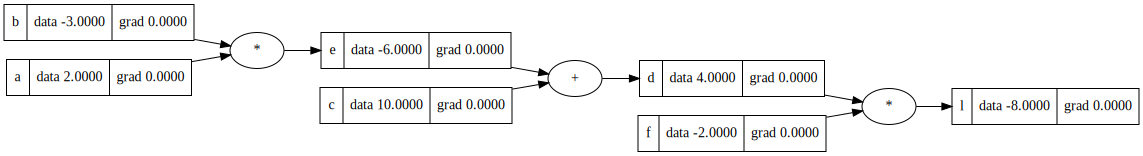

In [212]:
draw_dot(l)

Back propogation
####3
*  L=d*f
dL/dd=? f
*   we know how d impacts L from below now,so we have to somehow us that to know how c impacts L
*   dd/dc=> d=c+e 1.0 #again same
dd/de=1.0 #same(called local derivative,i call it)
((c+h +e)-(c+e))/h=>1
*  now just apply chain rule
*  dl/de=-2.0
e=a*b
de/da?b
dl/da=(dl/de)*(de/da)








In [213]:
a.grad=(-2.0*-3.0)
b.grad=(-2.0*2.0)

####2
L=d*f

dL/dd=? f

(f(x+h)-f(x))/h=>
  ((d+h)*f-d*f)/h
  =>df+hf-df/h==>f

In [214]:
f.grad=4.0
d.grad=-2.0



In [215]:
l.grad=1.0 # manual conclusion #1


In [216]:
def lol():
  h=0.0001
  a=Value(2.0,label='a')
  b=Value(-3.0,label='b')
  c=Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d'
  d
  f=Value(-2.0);f.label='f'
  l=d*f;l.label='l'
  l1=l.data

  a=Value(2.0,label='a')
  # a.data+=h
  b=Value(-3.0,label='b')
  # b.data+=h
  c=Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d';
  # d.data+=h
  f=Value(-2.0);f.label='f'
  l=d*f;l.label='l'
  l2=l.data
  print((l2-l1)/h)
lol()

0.0


In [217]:
#preview of single optimization
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad

f.data+=0.01*f.grad
e=a*b
d=e+c
l=d*f
print(l.data)

-7.325695999999999


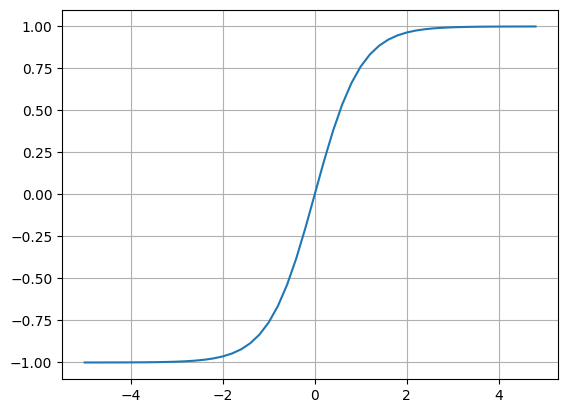

In [218]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid();

In [219]:
# one basic neuron
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.8813735870195432,label='b')


x1w1=x1*w1;x1w1.label="x1w1"
x2w2=x2*w2;x2w2.label="x2w2"
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label="x1*w1 + x2*w2"
n=x1w1x2w2 +b;n.label='n' #basic activation function
o=n.tanh();o.label="o"



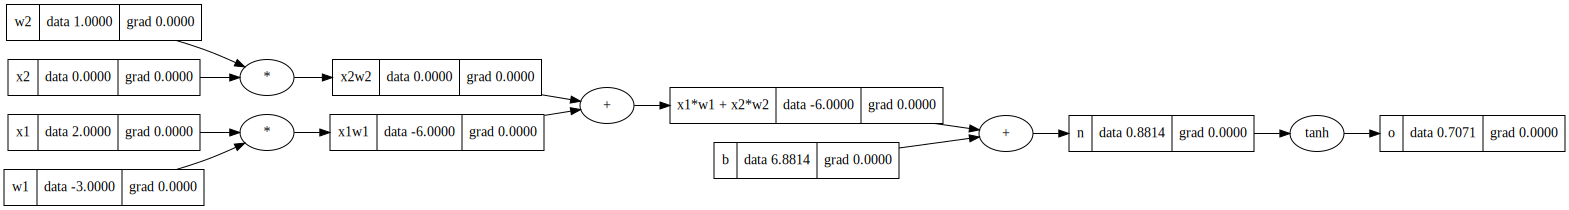

In [220]:
draw_dot(o)

In [221]:
#after adding backward function in value class
o.backward()

In [222]:
#newww

In [223]:
o.grad=1.0


In [224]:
o._backward()

In [225]:

n._backward()

In [226]:
b._backward()

In [227]:
x1w1x2w2._backward()

In [228]:
x1w1._backward()
x2w2._backward()

In [229]:
#old👇

In [230]:
o.grad=1.0
n.grad=0.5
x1w1x2w2.grad=0.5 #("+"=>distributed equally)
b.grad=0.5
x1w1.grad=0.5
x2w2.grad=0.5


In [231]:
#o=tanh(n)
#do/dn=1-tanh(n)**2

1-o.data**2

0.4999999999999999

In [232]:
x1.grad=w1.data * x1w1.grad
w1.grad=x1.data * x1w1.grad

In [233]:
x2.grad=w2.data * x2w2.grad
w2.grad=x2.data * x2w2.grad

In [234]:
##dont have to so this calc on own ,adding backward function in class Value 👆👆

In [235]:
#now moving further we are kinda from one operation backward function to whole graph
# for this we're using topological graph

In [236]:
o.grad=1.0
topo=[]
visited=set()
def build_topo(v):
  if v not in visited :
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
  node._backward()

In [237]:
topo=[]
visited=set()
def build_topo(v):
  if v not in visited :
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo


[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [238]:
#now adding it in value class check above

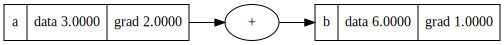

In [239]:
#fixing a backprop bug when one node is used multiple times
a=Value(3.0,label='a')
b=a+a ;b.label='b'  #two arrows should appear from a,or say two different a
b.backward()
draw_dot(b)
#updating the value class👆(+=)

In [240]:
# one basic neuron
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.8813735870195432,label='b')


x1w1=x1*w1;x1w1.label="x1w1"
x2w2=x2*w2;x2w2.label="x2w2"
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label="x1*w1 + x2*w2"
n=x1w1x2w2 +b;n.label='n' #basic activation function
o=n.tanh();o.label="o"
o.backward()


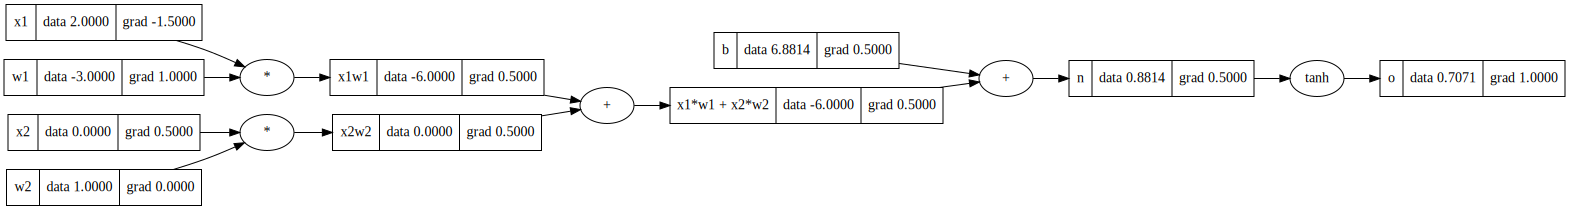

In [241]:
draw_dot(o)

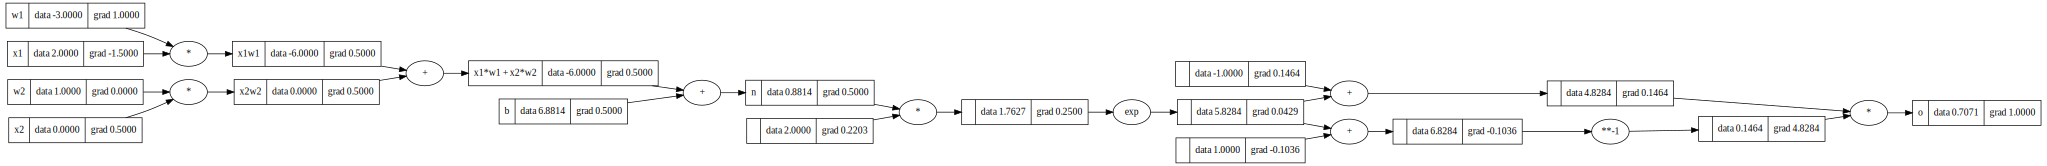

In [242]:
#breaking up the tanh function
# one basic neuron
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.8813735870195432,label='b')


x1w1=x1*w1;x1w1.label="x1w1"
x2w2=x2*w2;x2w2.label="x2w2"
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label="x1*w1 + x2*w2"
n=x1w1x2w2 +b;n.label='n' #basic activation function
#----------
e=(2*n).exp()
o=(e-1)/(e+1)
o.label="o"
o.backward()
draw_dot(o)

In [243]:
a=Value(2.0,label='a')
b=Value(0.0,label='b')
c=Value(-3.0,label='c')
print(2*a)
a/c


Value(data=4.0)


Value(data=-0.6666666666666666)

In [244]:
#division
# a/b
# a*(1/b)
# a*(b**-1)
# x**k

In [245]:
# implementing pytorch

In [246]:
import torch
#tensors with single element

In [247]:
x1=torch.Tensor([2.0]).double()         ;x1.requires_grad=True
x2=torch.Tensor([3.0]).double()         ;x2.requires_grad=True
w1=torch.Tensor([1.0]).double()         ;w1.requires_grad=True
w2=torch.Tensor([1.0]).double()         ;w2.requires_grad=True
b=torch.Tensor([6.8813735870195432]).double()  ;b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)
print(o.data.item())
o.backward()

print("------")
print('x2',x2.grad.item())
print('x1',x1.grad.item())
print('w2',w2.grad.item())
print('w1',w1.grad.item())

0.9999999999042806
------
x2 1.9143886475142248e-10
x1 1.9143886475142248e-10
w2 5.743165942542675e-10
w1 3.8287772950284496e-10


In [248]:
o.item() #o.dataitem() same result

0.9999999999042806

In [249]:
#neural network
class Neuron:
  def __init__(self,nin):
    self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b=Value(random.uniform(-1,1))
  def __call__(self,x):
    #w*x+b
    act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b) #creating pairs of weights with x
    out=act.tanh()
    return out
  def parameters(self):
      return self.w +[self.b]

class Layer:  #list of neurons to get a single layer
  def __init__(self,nin,nout):
    self.neurons=[Neuron(nin) for _ in range(nout)]
  def __call__(self,x):
    outs=[n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:  #list of layers to get a multi layer perceptron
    def __init__(self,nin,nouts):
      sz=[nin]+nouts
      self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
          x=layer(x)
        return x
    def parameters(self):
      return [p for layer in self.layers for p in layer.parameters()]

In [250]:
x=[2.0,3.0,-1.0]
n=Neuron(2)
n(x)

n2=Layer(2,3)
n2(x)

n3=MLP(3,[4,4,1])
n3(x)

Value(data=0.13294254025963143)

In [251]:
len(n3.parameters())

41

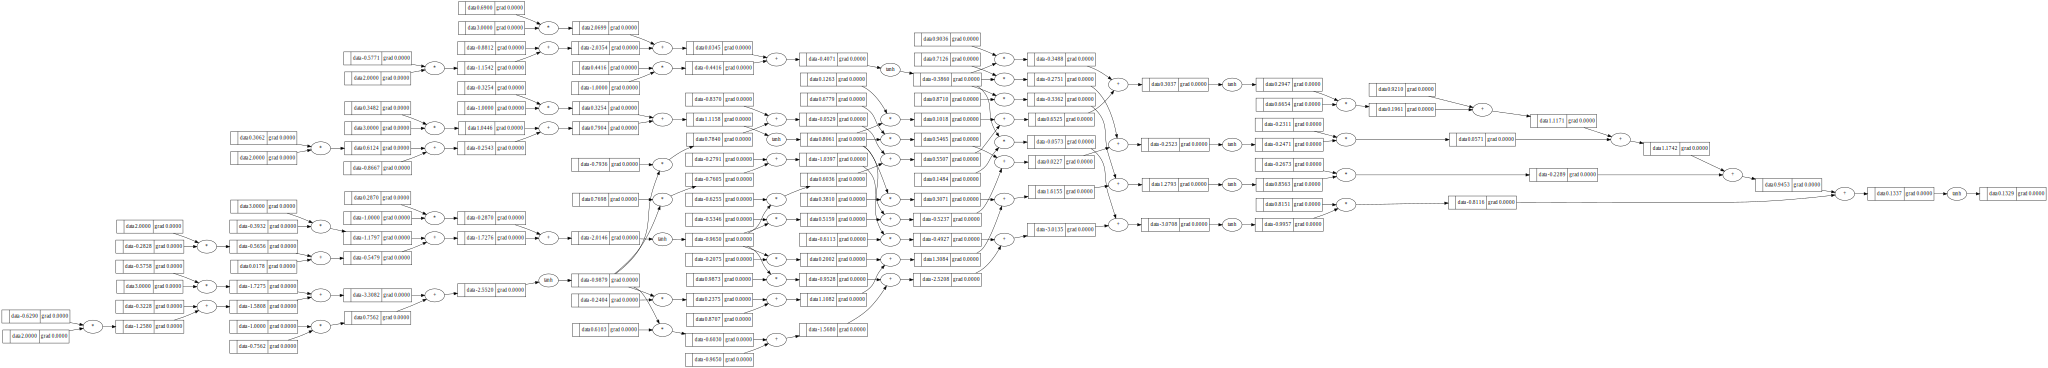

In [252]:
draw_dot(n3(x))

In [253]:
# simple binary classifier neural net
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys=[1.0,-1.0,-1.0,1.0] # desired targets


In [254]:
ypred=[n3(x) for x in xs]
ypred
loss=sum([(yout-ygt)**2 for ygt,yout in zip(ys,ypred)])
loss

Value(data=4.336667867453739)

In [255]:
loss.backward()

In [256]:
n3.layers[0].neurons[0].w[0].data

-0.628993595320005

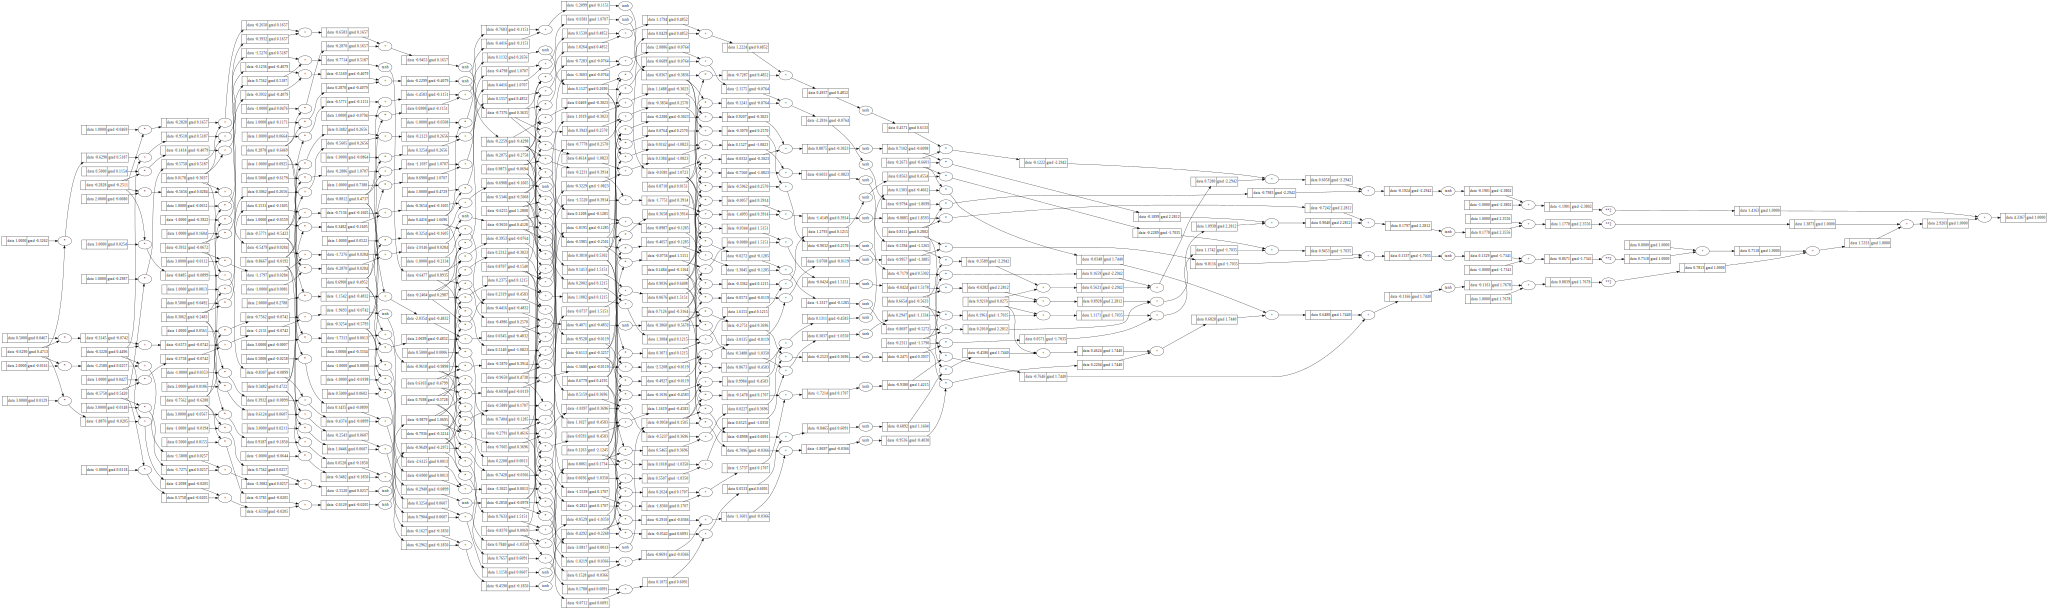

In [257]:
draw_dot(loss)

In [258]:
#gradient descent (gradient pointing in direction of loss)
for p in n3.parameters():
  p.data+=-0.01* p.grad


In [259]:
n3.layers[0].neurons[0].w[0].data

-0.6337070628900505

In [260]:
# 1. Re-initialize the network to get clean, random weights
n3 = MLP(3, [4, 4, 1])

# 2. Run a controlled 20-step loop
for k in range(20):

    # Forward Pass
    ypred = [n3(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

    # Zero Gradients (If you don't do this, the gradients accumulate and explode!)
    for p in n3.parameters():
        p.grad = 0.0

    # Backward Pass
    loss.backward()

    # Update Step (Stick to a small learning rate like 0.01)
    for p in n3.parameters():
        p.data += -0.01 * p.grad

    print(f"Step {k+1:2d} | Loss: {loss.data:.6f}")

Step  1 | Loss: 8.020755
Step  2 | Loss: 7.754884
Step  3 | Loss: 7.464065
Step  4 | Loss: 7.104161
Step  5 | Loss: 6.629859
Step  6 | Loss: 6.030734
Step  7 | Loss: 5.364299
Step  8 | Loss: 4.726076
Step  9 | Loss: 4.197462
Step 10 | Loss: 3.809654
Step 11 | Loss: 3.539759
Step 12 | Loss: 3.344774
Step 13 | Loss: 3.189557
Step 14 | Loss: 3.052342
Step 15 | Loss: 2.920955
Step 16 | Loss: 2.788931
Step 17 | Loss: 2.653347
Step 18 | Loss: 2.513790
Step 19 | Loss: 2.371621
Step 20 | Loss: 2.229096


In [261]:
ypred

[Value(data=0.525141205550822),
 Value(data=0.11584625292460063),
 Value(data=-0.5914334393960015),
 Value(data=0.2308668797937396)]

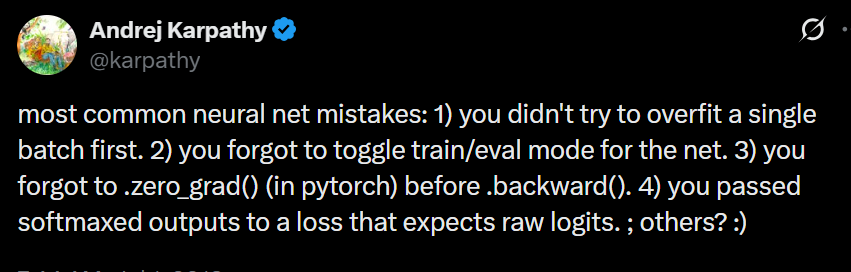

In [292]:
# fixing the 3rd ,how e
for k in range(20):

  #forward pass
  ypred=[n(x) for x in xs]
  loss=sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))

  #backward pass
  for p in n.parameters():
    p.grad=0.0   #zero grad handle
  loss.backward()
  #update
  for p in n.parameters():
    p.data+= -0.1*p.grad
  print(k,loss.data)

0 0.2080215037643637
1 0.20754672570850474
2 0.20707391814400325
3 0.2066030694852949
4 0.2061341682338304
5 0.2056672029772877
6 0.20520216238879246
7 0.20473903522614595
8 0.20427781033106157
9 0.20381847662840996
10 0.20336102312547116
11 0.2029054389111941
12 0.2024517131554665
13 0.20199983510838754
14 0.2015497940995542
15 0.20110157953734925
16 0.20065518090824064
17 0.20021058777608636
18 0.19976778978144616
19 0.1993267766409021


In [290]:
ypred

[Value(data=0.9999999999899537),
 Value(data=-0.8901714467441433),
 Value(data=-0.6760228821068167),
 Value(data=0.6814956374884726)]